In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

df = pd.read_csv('./results/grg_comparison.csv')

METHODS    = ['MDS', 's_gd2', 'wrap_python', 'TorusMDS']
COLORS     = {'MDS': '#4C72B0', 's_gd2': '#DD8452', 'wrap_python': '#C44E52', 'TorusMDS': '#55A868'}
GT_COLORS  = {'euclidean': '#7BB3D4', 'toroidal': '#E8896A'}   # tints for graph-type plots
GT_HATCH   = {'euclidean': '', 'toroidal': '///'}
GRAPH_TYPES = ['euclidean', 'toroidal']
METRICS    = ['stress', 'distortion', 'sgs', 'np_score']
LABELS     = {
    'stress':     'Normalized stress',
    'distortion': 'Distortion',
    'sgs':        'SGS (Spearman rank corr.)',
    'np_score':   'Neighbourhood preservation',
    't_embed':    'Embedding time (s)',
}

TOROIDAL_ONLY = False
if TOROIDAL_ONLY:
    df = df[df['graph_type'] == 'toroidal']

data = {m: df[df['method'] == m] for m in METHODS}
print('--- overall ---')
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean','std']).round(4))
print('\n--- by graph type ---')
print(df.groupby(['method', 'graph_type'])[METRICS].mean().round(4))

--- overall ---
             stress         distortion             sgs         np_score  \
               mean     std       mean     std    mean     std     mean   
method                                                                    
MDS          0.2259  0.1079     0.1908  0.0878  0.7875  0.1717   0.8388   
TorusMDS     0.2040  0.0897     0.1681  0.0664  0.8179  0.1457   0.8389   
s_gd2        0.2373  0.1148     0.1931  0.0870  0.7674  0.1901   0.8343   
wrap_python  0.2071  0.0835     0.1653  0.0631  0.8126  0.2100   0.8915   

                    t_embed          
                std    mean     std  
method                               
MDS          0.1943  1.9978  3.4750  
TorusMDS     0.1449  1.5006  0.9889  
s_gd2        0.2037  0.1312  0.2138  
wrap_python  0.1519  1.1999  1.6336  

--- by graph type ---
                        stress  distortion     sgs  np_score
method      graph_type                                      
MDS         euclidean   0.1178      0.1042  0.9

## Violin plots

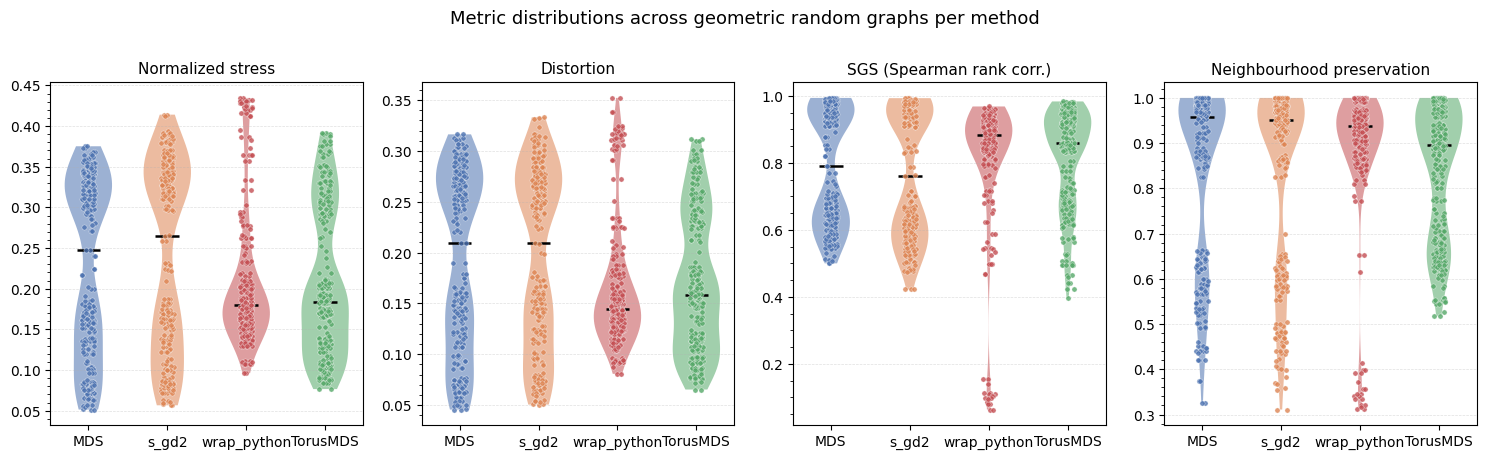

In [2]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=14, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.8)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)

fig.suptitle('Metric distributions across geometric random graphs per method', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('./results/grg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Euclidean vs Toroidal GRG: metrics by graph type

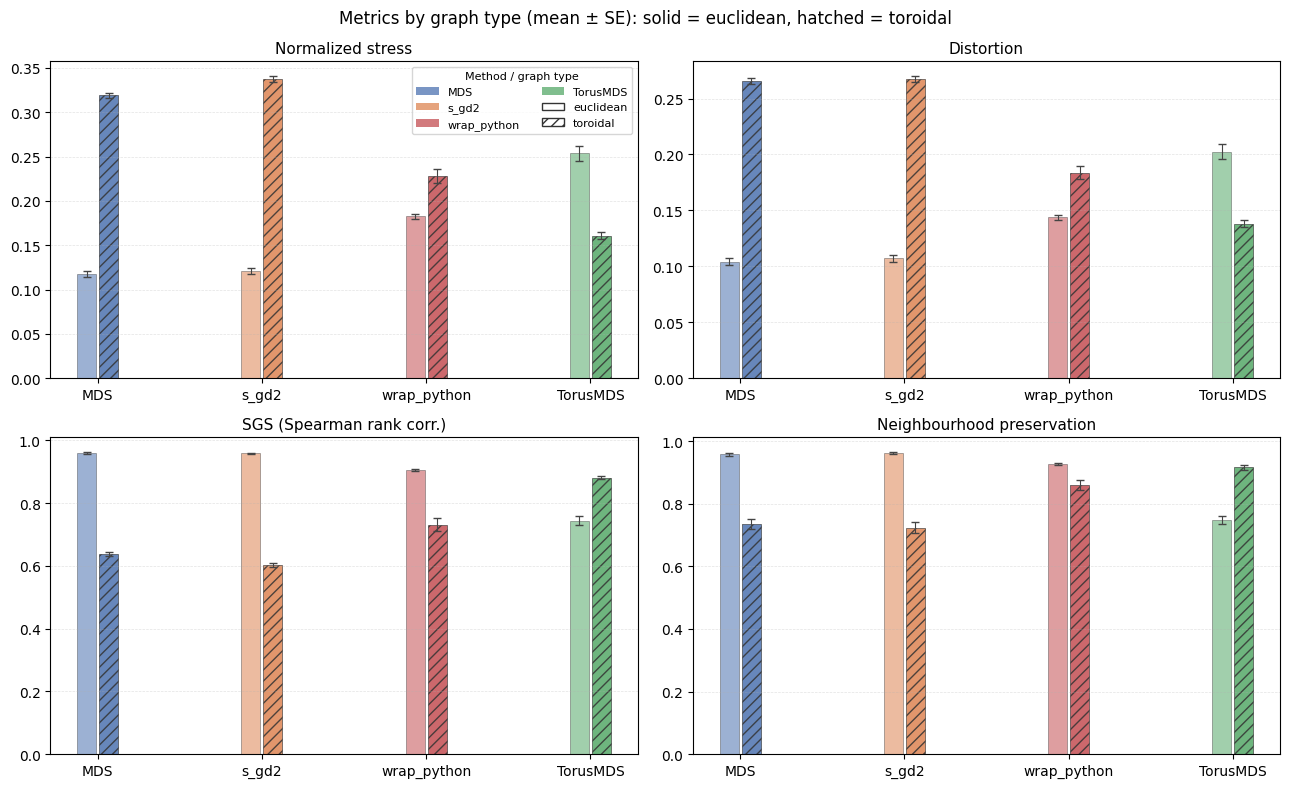

In [3]:
# For each method, show side-by-side bars for euclidean and toroidal graphs.

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
n_gt = len(GRAPH_TYPES)   # 2
n_m  = len(METHODS)       # 3
group_w = 0.8
bar_w   = group_w / (n_m * n_gt + 1)

x_base = np.arange(n_m)

for ax, metric in zip(axes.flat, METRICS):
    handles = []
    for gi, gt in enumerate(GRAPH_TYPES):
        for mi, m in enumerate(METHODS):
            sub = data[m][data[m]['graph_type'] == gt]
            mean_val = sub[metric].mean()
            sem_val  = sub[metric].sem()
            offset = x_base[mi] + (gi - (n_gt - 1) / 2) * bar_w * 1.5
            bar = ax.bar(
                offset, mean_val, width=bar_w * 1.3,
                color=COLORS[m], alpha=0.55 + 0.3 * gi,
                hatch=GT_HATCH[gt], edgecolor='#333', linewidth=0.5,
                yerr=sem_val, capsize=3,
                error_kw=dict(elinewidth=0.8, ecolor='#444'),
                label=f'{m} / {gt}' if metric == METRICS[0] else '_',
            )
            if metric == METRICS[0]:
                handles.append(bar)

    ax.set_xticks(x_base)
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

# Shared legend: solid = euclidean, hatched = toroidal
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS[m], alpha=0.75, label=m) for m in METHODS
] + [
    Patch(facecolor='white', edgecolor='#333', hatch=h, label=gt)
    for gt, h in GT_HATCH.items()
]
axes.flat[0].legend(handles=legend_elements, fontsize=8, title_fontsize=8,
                    title='Method / graph type', ncol=2)

fig.suptitle('Metrics by graph type (mean ± SE): solid = euclidean, hatched = toroidal', fontsize=12)
fig.tight_layout()
plt.savefig('./results/grg_metrics_by_graph_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs graph size n

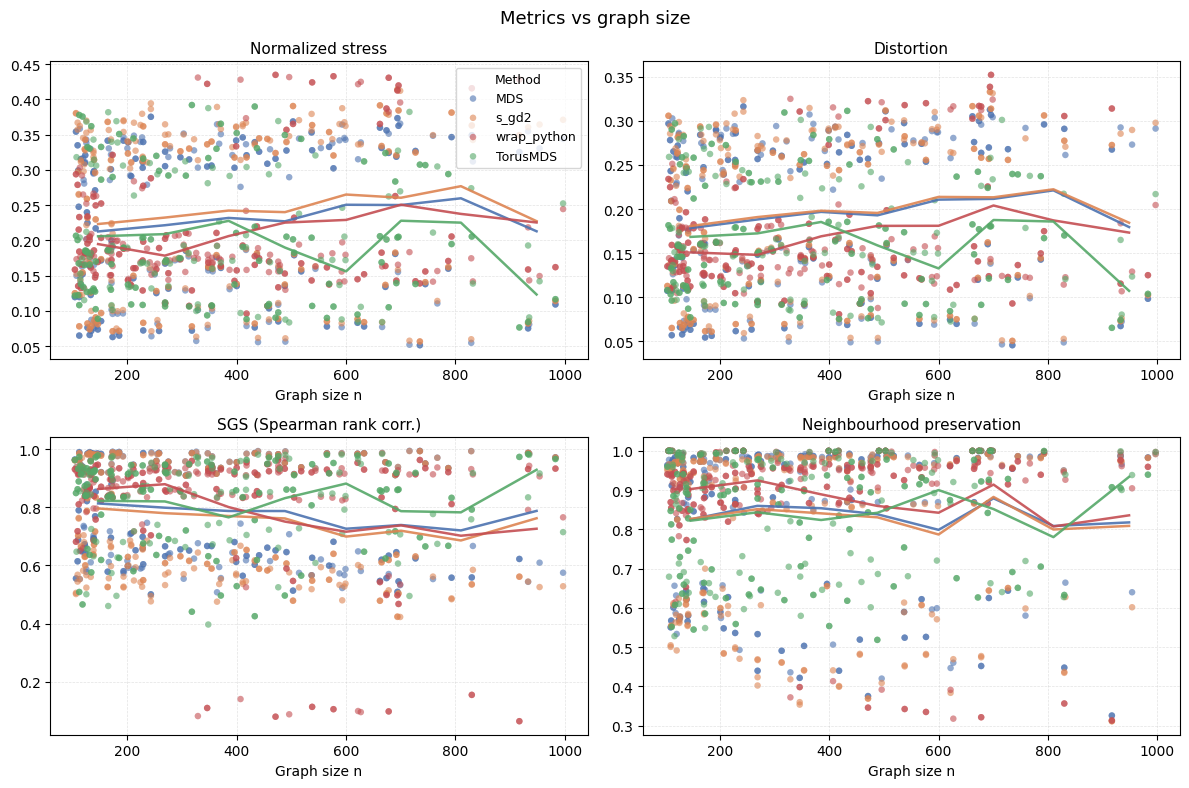

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axes.flat, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=22, color=COLORS[m],
                   alpha=0.6, label=m, edgecolors='none')
        # LOWESS-style trend via binned means
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes.flat[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs graph size', fontsize=13)
fig.tight_layout()
plt.savefig('./results/grg_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()

## Running time distributions

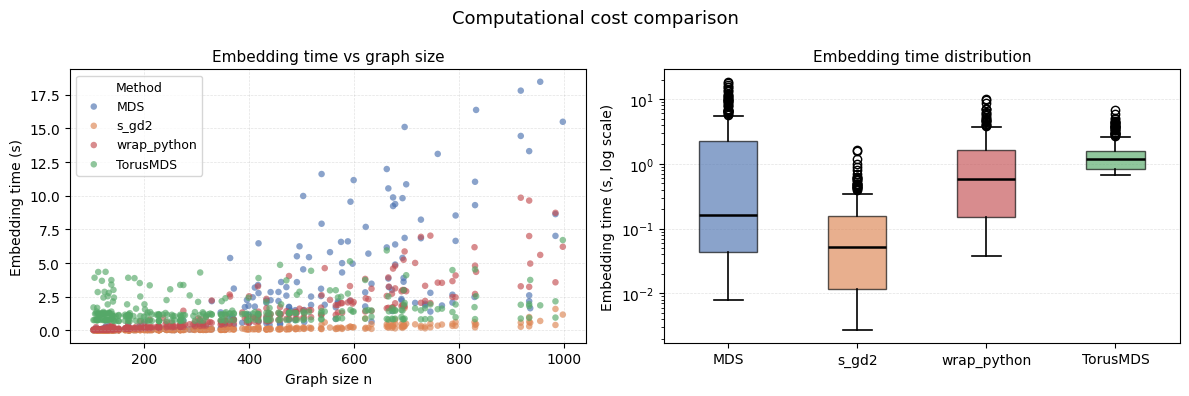

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter t_embed vs n
ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=22, color=COLORS[m],
               alpha=0.65, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=9, title_fontsize=9)
ax.grid(linestyle='--', alpha=0.35)

# Right: log-scale box plot
ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison', fontsize=13)
fig.tight_layout()
plt.savefig('./results/grg_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [6]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.round(4)
summary

,stress_mean,stress_median,stress_std,distortion_mean,distortion_median,distortion_std,sgs_mean,sgs_median,sgs_std,np_score_mean,np_score_median,np_score_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,,,,,,,
MDS,0.2259,0.2476,0.1079,0.1908,0.2092,0.0878,0.7875,0.7894,0.1717,0.8388,0.9572,0.1943,1.9978,0.1600,3.4750
TorusMDS,0.2040,0.1841,0.0897,0.1681,0.1583,0.0664,0.8179,0.8597,0.1457,0.8389,0.8956,0.1449,1.5006,1.2054,0.9889
s_gd2,0.2373,0.2652,0.1148,0.1931,0.2090,0.0870,0.7674,0.7621,0.1901,0.8343,0.9516,0.2037,0.1312,0.0513,0.2138
wrap_python,0.2071,0.1796,0.0835,0.1653,0.1450,0.0631,0.8126,0.8842,0.2100,0.8915,0.9382,0.1519,1.1999,0.5808,1.6336
